# Microwave-optical transduction fidelity

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from src import *
from src.params import *
from src.plots import *

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

### Parameters

In [2]:
# Devices to compare (extracavity transduction).
scenarios = {
    'Rochman et al.' : ROCHMAN_PARAMS,
    'King et al.' : KING_PARAMS,
}

# Out-coupling: False uses the experimental values; True sets eta_a = eta_b = 1.
IDEAL_COUPLING = False

# Parasitic squeezing ratio z = |g_bp/g_bs|. None uses the theory value from Delta_a.
Z_OVERRIDE = None

# Mean photon numbers of the microwave input state.
n_fock   = np.arange(0, 11)                 # Number states (integer).
nbar_coh = np.linspace(0.001, 10.0, 21)     # Coherent states.
nbar_gkp = np.linspace(0.001, 10.0, 21)     # GKP states (fidelity grid cost ~ nbar**2).
nbar_eff = np.linspace(0.001, 10.0, 21)     # Efficiency sweep.

### Numerics

In [3]:
LOGICAL_0 = np.array([[1, 0], [0, 0]], dtype=complex)   # Ideal logical |0>.


def gkp_state_fidelity(nbar, moments):
    """State fidelity of a transduced GKP |0>, sized integration grid (App. F1)."""
    return fidelity(lambda w: Phi_gkp(w, nbar), *moments, *integration_grid('gkp', nbar))


def input_second_moment(chi, eps=1e-3):
    """<b_in^2> from a characteristic function chi(z), by finite differences at z = 0."""
    c0 = chi(np.array(0j))
    dxx = (chi(np.array(eps + 0j))       - 2*c0 + chi(np.array(-eps + 0j)))      / eps**2
    dyy = (chi(np.array(1j*eps))         - 2*c0 + chi(np.array(-1j*eps)))        / eps**2
    dxy = (chi(np.array(eps + 1j*eps)) - chi(np.array(eps - 1j*eps))
           - chi(np.array(-eps + 1j*eps)) + chi(np.array(-eps - 1j*eps)))        / (4*eps**2)
    return 0.25*(dxx - dyy + 2j*dxy)


# Transduction quality for each device and input state.
results = {}
for name, params in scenarios.items():

    if IDEAL_COUPLING:
        params = {**params, 'eta_a': 1.0, 'eta_b': 1.0}

    # Transducer at the transduction resonance, Delta = +omega_b.
    transducer = Transducer.from_params(params, Delta=params['omega_b'])

    # Parasitic two-mode squeezing relative to transduction, z = |g_bp/g_bs|.
    z = Z_OVERRIDE if Z_OVERRIDE is not None else 1 / abs(1 - (params['omega_b'] / params['Delta_a'])**2)

    # Impedance-matched beam-splitter rate and the parasitic squeezing rate.
    g_t = np.sqrt(params['kappa_a'] * params['kappa_b']) / 2
    g_s = z * g_t

    # Noise moments of the optical output at the central frequency of transduction.
    moments = aout_moments(*transducer.channel(params['omega_b'], g_t, g_s))
    S_12, S_14, expect_NdN, *_ = moments

    # Measured efficiency vs n̄ per input state (main text Eq. eta-meas). The state
    # enters only through <b_in^2> and the phase-sensitive gain G_phi ~ |S_14|;
    # here S_14 ~ z kappa_b / 4 omega_b ~ 1e-4, so the three curves coincide.
    b_sq = {
        'Number'  : np.zeros_like(nbar_eff),
        'Coherent': nbar_eff.astype(complex),
        'GKP'     : np.array([input_second_moment(lambda w: Phi_gkp(w, nb)) for nb in nbar_eff]),
    }
    eff = {s: measured_efficiency(nbar_eff, S_12, S_14, expect_NdN, bs)
           for s, bs in b_sq.items()}

    # State fidelity: number, coherent, GKP |0>.
    F_fock = np.array([fidelity(lambda w: Phi_fock(w, n), *moments,
                                *integration_grid('fock', n)) for n in n_fock])
    F_coh  = np.array([fidelity(lambda w: Phi_coherent(w, np.sqrt(nb)), *moments,
                                *integration_grid('coherent', nb)) for nb in nbar_coh])
    F_gkp  = np.array(Parallel(n_jobs=-1)(
        delayed(gkp_state_fidelity)(nb, moments) for nb in nbar_gkp))

    # GKP logical fidelity: decoded (numerical, App. F3) vs analytic 1 - Fbar (App. F2).
    F_dec = np.array([
        logical_fidelity(
            decoded_rho(lambda w: Phi_out(w, lambda v: Phi_gkp(v, nb, mu=0), *moments), trunc=12),
            LOGICAL_0)
        for nb in nbar_gkp])
    chan  = gkp_channel_params(params['kappa_a'], params['kappa_b'], params['omega_b'],
                               z, params['eta_a'], params['eta_b'])
    F_ana = 1 - np.array([gkp_infidelity(nb, *chan) for nb in nbar_gkp])

    results[name] = dict(z=z, eff=eff,
                         F_fock=F_fock, F_coh=F_coh, F_gkp=F_gkp,
                         F_dec=F_dec, F_ana=F_ana)

for name, r in results.items():
    print(f"{name}: z = |g_bp/g_bs| = {r['z']:.2e}")

Rochman et al.: z = |g_bp/g_bs| = 4.10e-04
King et al.: z = |g_bp/g_bs| = 8.60e-04


### Figure

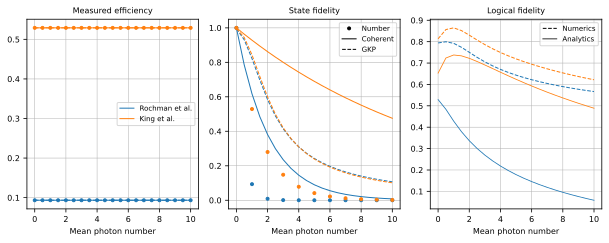

In [4]:
# Figure setup.
fig, axs = plt.subplots(
    nrows = 1,
    ncols = 3,
    figsize = (
        2.5 * FIG_SIZES['onecol'],
        1 * FIG_SIZES['onecol']
        ),
    sharex = True,
    )

colors = {'Rochman et al.': 'tab:blue', 'King et al.': 'tab:orange'}

# State styles: number (markers), coherent (solid), GKP (dashed).
number_kw   = dict(marker='o', ms=3, ls='')
coherent_kw = dict(ls='-')
gkp_kw      = dict(ls='--')

# Ideal coupling: metrics sit at ~1, so plot |1 - x| on a log axis (the transducer
# has gain, so 1 - eta can be negative -- hence the absolute value).
if IDEAL_COUPLING:
    y = lambda x: np.abs(1 - x)
    titles = ['Efficiency error $|1-\\eta|$', 'State infidelity', 'Logical infidelity']
else:
    y = lambda x: x
    titles = ['Measured efficiency', 'State fidelity', 'Logical fidelity']

for name, r in results.items():
    c = colors[name]

    # Efficiency vs n̄ per input state (curves coincide).
    axs[0].plot(nbar_eff, y(r['eff']['Number']),   color=c, **number_kw)
    axs[0].plot(nbar_eff, y(r['eff']['Coherent']), color=c, **coherent_kw)
    axs[0].plot(nbar_eff, y(r['eff']['GKP']),      color=c, **gkp_kw)

    # State fidelity per input state.
    axs[1].plot(n_fock,   y(r['F_fock']), color=c, **number_kw)
    axs[1].plot(nbar_coh, y(r['F_coh']),  color=c, **coherent_kw)
    axs[1].plot(nbar_gkp, y(r['F_gkp']),  color=c, **gkp_kw)

    # GKP logical fidelity: numerical (dashed), analytic F2 (thin solid).
    axs[2].plot(nbar_gkp, y(r['F_dec']), color=c, ls='--')
    axs[2].plot(nbar_gkp, y(r['F_ana']), color=c, ls='-', lw=0.8)

# Legend proxies.
for name, c in colors.items():
    axs[0].plot([], [], color=c, label=name)
for lbl, kw in [('Number', number_kw), ('Coherent', coherent_kw), ('GKP', gkp_kw)]:
    axs[1].plot([], [], 'k', label=lbl, **kw)
axs[2].plot([], [], 'k', ls='--', label='Numerics')
axs[2].plot([], [], 'k', ls='-', lw=0.8, label='Analytics')

for ax, title in zip(axs, titles):
    ax.set_title(title)
    ax.grid('both')
    ax.set_xlabel('Mean photon number')
    ax.legend()
    if IDEAL_COUPLING:
        ax.set_yscale('log')

fig.tight_layout()
fig.savefig('fig/transduction.pdf', bbox_inches='tight')